MLCV HOME ASSIGNMENT – 01

Performance Evaluation of Deep Learning Optimization and Regularization Techniques for Multi-Class Product Classification

Name : sudarshan chaudhari

Roll No : 6

div : G 

61,878 samples
93 numerical features
9 output classes

In [2]:
# ================================
# Import Libraries
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version :", tf.__version__)
print("NumPy Version :", np.__version__)
print("Pandas Version :", pd.__version__)

TensorFlow Version : 2.21.0
NumPy Version : 2.5.1
Pandas Version : 3.0.3


In [2]:
import tensorflow as tf

print("GPU Available :", tf.config.list_physical_devices('GPU'))

GPU Available : []


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\sudar\Documents\Collage\Placement prep\Machine learing and computer vison\Home Assignment\train.csv")

# Display first 5 rows
df.head()

,id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,target
0,1,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,Class_1
1,2,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
2,3,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
3,4,1,0,0,1,6,1,5,0,0,...,0,1,2,0,0,0,0,0,0,Class_1
4,5,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,Class_1


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (61878, 95)


In [5]:
print(df.columns)

Index(['id', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6',
       'feat_7', 'feat_8', 'feat_9', 'feat_10', 'feat_11', 'feat_12',
       'feat_13', 'feat_14', 'feat_15', 'feat_16', 'feat_17', 'feat_18',
       'feat_19', 'feat_20', 'feat_21', 'feat_22', 'feat_23', 'feat_24',
       'feat_25', 'feat_26', 'feat_27', 'feat_28', 'feat_29', 'feat_30',
       'feat_31', 'feat_32', 'feat_33', 'feat_34', 'feat_35', 'feat_36',
       'feat_37', 'feat_38', 'feat_39', 'feat_40', 'feat_41', 'feat_42',
       'feat_43', 'feat_44', 'feat_45', 'feat_46', 'feat_47', 'feat_48',
       'feat_49', 'feat_50', 'feat_51', 'feat_52', 'feat_53', 'feat_54',
       'feat_55', 'feat_56', 'feat_57', 'feat_58', 'feat_59', 'feat_60',
       'feat_61', 'feat_62', 'feat_63', 'feat_64', 'feat_65', 'feat_66',
       'feat_67', 'feat_68', 'feat_69', 'feat_70', 'feat_71', 'feat_72',
       'feat_73', 'feat_74', 'feat_75', 'feat_76', 'feat_77', 'feat_78',
       'feat_79', 'feat_80', 'feat_81', 'feat_82', 'fe

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61878 entries, 0 to 61877
Data columns (total 95 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       61878 non-null  int64
 1   feat_1   61878 non-null  int64
 2   feat_2   61878 non-null  int64
 3   feat_3   61878 non-null  int64
 4   feat_4   61878 non-null  int64
 5   feat_5   61878 non-null  int64
 6   feat_6   61878 non-null  int64
 7   feat_7   61878 non-null  int64
 8   feat_8   61878 non-null  int64
 9   feat_9   61878 non-null  int64
 10  feat_10  61878 non-null  int64
 11  feat_11  61878 non-null  int64
 12  feat_12  61878 non-null  int64
 13  feat_13  61878 non-null  int64
 14  feat_14  61878 non-null  int64
 15  feat_15  61878 non-null  int64
 16  feat_16  61878 non-null  int64
 17  feat_17  61878 non-null  int64
 18  feat_18  61878 non-null  int64
 19  feat_19  61878 non-null  int64
 20  feat_20  61878 non-null  int64
 21  feat_21  61878 non-null  int64
 22  feat_22  61878 non-null  int64
 2

In [7]:
df.describe()

,id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93
count,61878.000000,61878.00000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,...,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000
mean,30939.500000,0.38668,0.263066,0.901467,0.779081,0.071043,0.025696,0.193704,0.662433,1.011296,...,0.070752,0.532306,1.128576,0.393549,0.874915,0.457772,0.812421,0.264941,0.380119,0.126135
std,17862.784315,1.52533,1.252073,2.934818,2.788005,0.438902,0.215333,1.030102,2.255770,3.474822,...,1.151460,1.900438,2.681554,1.575455,2.115466,1.527385,4.597804,2.045646,0.982385,1.201720
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15470.250000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,30939.500000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,46408.750000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,61878.000000,61.00000,51.000000,64.000000,70.000000,19.000000,10.000000,38.000000,76.000000,43.000000,...,76.000000,55.000000,65.000000,67.000000,30.000000,61.000000,130.000000,52.000000,19.000000,87.000000


In [8]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
id         0
feat_1     0
feat_2     0
feat_3     0
feat_4     0
          ..
feat_90    0
feat_91    0
feat_92    0
feat_93    0
target     0
Length: 95, dtype: int64


In [9]:
print("\nTotal Missing Values:", missing_values.sum())


Total Missing Values: 0


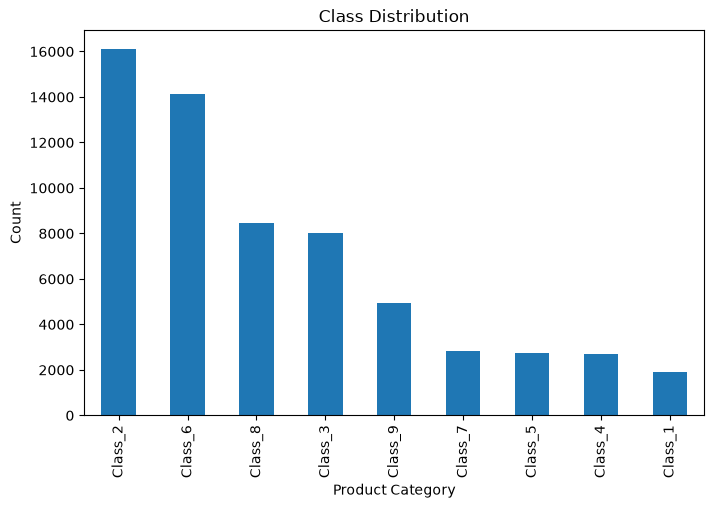

In [10]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Class Distribution")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

In [11]:
# Separate input features and target

X = df.drop(columns=["id", "target"])
y = df["target"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (61878, 93)
Target Shape : (61878,)


In [12]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded Labels:")
print(y_encoded[:10])

Encoded Labels:
[0 0 0 0 0 0 0 0 0 0]


In [13]:
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'Class_1': np.int64(0), 'Class_2': np.int64(1), 'Class_3': np.int64(2), 'Class_4': np.int64(3), 'Class_5': np.int64(4), 'Class_6': np.int64(5), 'Class_7': np.int64(6), 'Class_8': np.int64(7), 'Class_9': np.int64(8)}


In [14]:
import numpy as np

print(np.unique(y_encoded))

[0 1 2 3 4 5 6 7 8]


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape :", X_scaled.shape)

Scaled Feature Shape : (61878, 93)


In [16]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Set :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Test Set :", X_test.shape)

Training Set : (43314, 93)
Validation Set : (9282, 93)
Test Set : (9282, 93)


In [17]:
from tensorflow.keras.utils import to_categorical

Y_train = to_categorical(y_train)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

print("One-Hot Encoded Training Labels:", Y_train.shape)
print("One-Hot Encoded Validation Labels:", Y_val.shape)
print("One-Hot Encoded Test Labels:", Y_test.shape)

One-Hot Encoded Training Labels: (43314, 9)
One-Hot Encoded Validation Labels: (9282, 9)
One-Hot Encoded Test Labels: (9282, 9)


70% Training
15% Validation
15% Test

In [18]:
from tensorflow.keras.utils import to_categorical

Y_train = to_categorical(y_train)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

print("Y_train:", Y_train.shape)
print("Y_val:", Y_val.shape)
print("Y_test:", Y_test.shape)

Y_train: (43314, 9)
Y_val: (9282, 9)
Y_test: (9282, 9)


Data Preprocessing Justification

The id column was removed because it is only a unique identifier and does not contribute to classification.
The target labels were encoded into numerical values using LabelEncoder.
The input features were standardized using StandardScaler to improve neural network convergence and training stability.
The dataset was split into training (70%), validation (15%), and test (15%) sets to train the model, tune hyperparameters, and evaluate its final performance on unseen data.

Neural Network Architecture
Input:       93
             ↓
Hidden 1:   256
             ↓
Hidden 2:   128
             ↓
Hidden 3:    64
             ↓
Hidden 4:    32
             ↓
Output:       9
Softmax converts the raw output scores into probabilities.

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# ==============================
# Baseline Model
# ==============================

model = Sequential([
    Dense(256, activation='relu', input_shape=(93,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(9, activation='softmax')
])

model.summary()

c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,593 (264.04 KB)

 Trainable params: 67,593 (264.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
optimizer = SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Traning - The neural network repeatedly adjusts its weights so that its predictions become closer to the correct answers.

In [21]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200


1333/1354 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6676 - loss: 1.0077

KeyboardInterrupt: 

32 samples
→ update weights

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 1.7598
Test Accuracy: 0.7819


In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


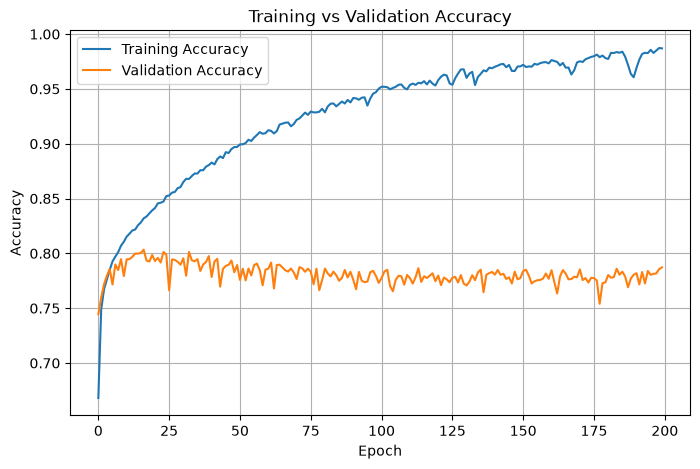

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

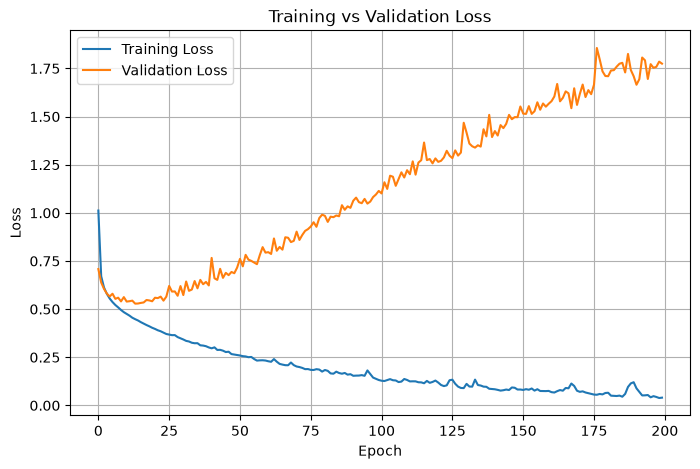

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 1.7598
Test Accuracy : 0.7819


In [ ]:
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded labels back to class indices
y_true = np.argmax(Y_test, axis=1)

291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


<Figure size 800x800 with 0 Axes>

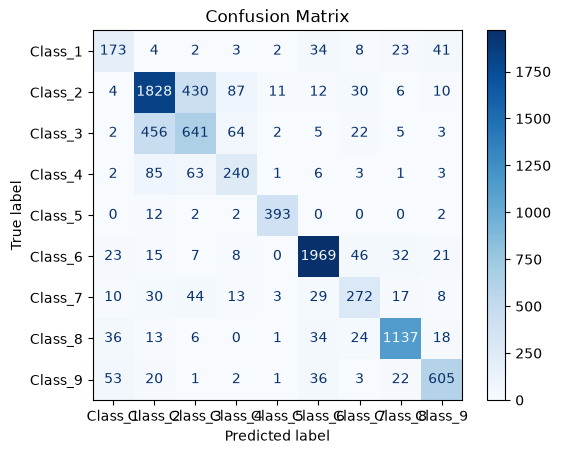

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

     Class_1       0.57      0.60      0.58       290
     Class_2       0.74      0.76      0.75      2418
     Class_3       0.54      0.53      0.54      1200
     Class_4       0.57      0.59      0.58       404
     Class_5       0.95      0.96      0.95       411
     Class_6       0.93      0.93      0.93      2121
     Class_7       0.67      0.64      0.65       426
     Class_8       0.91      0.90      0.91      1269
     Class_9       0.85      0.81      0.83       743

    accuracy                           0.78      9282
   macro avg       0.75      0.75      0.75      9282
weighted avg       0.78      0.78      0.78      9282



In [ ]:
baseline_results = {
    "Optimizer": "SGD",
    "Train Accuracy": history.history["accuracy"][-1],
    "Validation Accuracy": history.history["val_accuracy"][-1],
    "Test Accuracy": test_accuracy,
    "Train Loss": history.history["loss"][-1],
    "Validation Loss": history.history["val_loss"][-1],
    "Test Loss": test_loss
}

print(baseline_results)

{'Optimizer': 'SGD', 'Train Accuracy': 0.9869788289070129, 'Validation Accuracy': 0.7872225642204285, 'Test Accuracy': 0.7819435596466064, 'Train Loss': 0.040295206010341644, 'Validation Loss': 1.7749197483062744, 'Test Loss': 1.759770393371582}


In [ ]:
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

In [ ]:
from tensorflow.keras.optimizers import AdamW

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model():

    model = Sequential([

        Dense(256, activation='relu', input_shape=(93,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(9, activation='softmax')

    ])

    return model

In [ ]:
def train_model(optimizer, optimizer_name):

    model = build_model()

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(

        X_train,
        Y_train,

        validation_data=(X_val, Y_val),

        epochs=200,
        batch_size=32,
        verbose=1

    )

    test_loss, test_accuracy = model.evaluate(
        X_test,
        Y_test,
        verbose=0
    )

    result = {

        "Optimizer": optimizer_name,

        "Training Accuracy":
            history.history["accuracy"][-1],

        "Validation Accuracy":
            history.history["val_accuracy"][-1],

        "Test Accuracy":
            test_accuracy,

        "Training Loss":
            history.history["loss"][-1],

        "Validation Loss":
            history.history["val_loss"][-1],

        "Test Loss":
            test_loss,

        "Epochs":
            len(history.history["loss"])

    }

    return history, result

In [ ]:
results = []

SGD: Updates weights using the gradient of the loss and a fixed learning rate.

In [ ]:
history_sgd, result_sgd = train_model(

    SGD(learning_rate=0.01),

    "SGD"

)

results.append(result_sgd)

Epoch 1/200


c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6468 - loss: 1.0438 - val_accuracy: 0.7432 - val_loss: 0.7062
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7486 - loss: 0.6741 - val_accuracy: 0.7610 - val_loss: 0.6421
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7651 - loss: 0.6141 - val_accuracy: 0.7717 - val_loss: 0.6117
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7765 - loss: 0.5808 - val_accuracy: 0.7782 - val_loss: 0.5777
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7833 - loss: 0.5570 - val_accuracy: 0.7680 - val_loss: 0.5891
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7911 - loss: 0.5402 - val_accuracy: 0.7829 - val_loss: 0.5596
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7934 - loss: 0.5247 - val_accuracy: 0.7897 - val_loss: 0.5495
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7989 - loss: 0.5102 - val_

In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
[]


SGD + Momentum: Adds previous update information to SGD to accelerate learning and reduce oscillations.

In [ ]:
history_momentum, result_momentum = train_model(
    SGD(learning_rate=0.01, momentum=0.9),
    "SGD + Momentum"
)

results.append(result_momentum)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7326 - loss: 0.7179 - val_accuracy: 0.7669 - val_loss: 0.6036
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7767 - loss: 0.5728 - val_accuracy: 0.7891 - val_loss: 0.5496
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7903 - loss: 0.5351 - val_accuracy: 0.7888 - val_loss: 0.5406
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7975 - loss: 0.5084 - val_accuracy: 0.7930 - val_loss: 0.5360
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8050 - loss: 0.4875 - val_accuracy: 0.7926 - val_loss: 0.5431
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8126 - loss: 0.4665 - val_accuracy: 0.7908 - val_loss: 0.5555
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8192 - loss: 0.4517 - val_accuracy: 0.7908 - val_loss: 0.5327
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8239 - loss: 0

RMSprop: Adapts the learning rate for each parameter using recent squared gradients.

In [ ]:
history_rmsprop, result_rmsprop = train_model(
    RMSprop(learning_rate=0.001),
    "RMSprop"
)

results.append(result_rmsprop)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7492 - loss: 0.6850 - val_accuracy: 0.7708 - val_loss: 0.6012
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7836 - loss: 0.5722 - val_accuracy: 0.7927 - val_loss: 0.5492
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7951 - loss: 0.5370 - val_accuracy: 0.7926 - val_loss: 0.5353
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8034 - loss: 0.5128 - val_accuracy: 0.7955 - val_loss: 0.5296
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8106 - loss: 0.4911 - val_accuracy: 0.7975 - val_loss: 0.5289
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8163 - loss: 0.4794 - val_accuracy: 0.7973 - val_loss: 0.5642
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8213 - loss: 0.4665 - val_accuracy: 0.8023 - val_loss: 0.5815
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8238 - loss: 0

Adam: Combines momentum-like gradient averaging with adaptive learning rates for efficient weight updates.

In [ ]:
history_adam, result_adam = train_model(
    Adam(learning_rate=0.001),
    "Adam"
)

results.append(result_adam)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7426 - loss: 0.6890 - val_accuracy: 0.7730 - val_loss: 0.5792
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7836 - loss: 0.5560 - val_accuracy: 0.7778 - val_loss: 0.5571
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7937 - loss: 0.5190 - val_accuracy: 0.7935 - val_loss: 0.5308
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8068 - loss: 0.4901 - val_accuracy: 0.7977 - val_loss: 0.5282
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8152 - loss: 0.4660 - val_accuracy: 0.7929 - val_loss: 0.5299
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8228 - loss: 0.4448 - val_accuracy: 0.7984 - val_loss: 0.5353
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8289 - loss: 0.4279 - val_accuracy: 0.7967 - val_loss: 0.5494
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8374 - loss: 0

AdamW: Adam with decoupled weight decay, which helps control weight magnitude and improve generalization.

In [ ]:
history_adamw, result_adamw = train_model(
    AdamW(learning_rate=0.001),
    "AdamW"
)

results.append(result_adamw)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7471 - loss: 0.6816 - val_accuracy: 0.7715 - val_loss: 0.5920
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7822 - loss: 0.5595 - val_accuracy: 0.7882 - val_loss: 0.5470
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7938 - loss: 0.5206 - val_accuracy: 0.7851 - val_loss: 0.5437
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8051 - loss: 0.4933 - val_accuracy: 0.7926 - val_loss: 0.5348
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8142 - loss: 0.4663 - val_accuracy: 0.7856 - val_loss: 0.5388
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8195 - loss: 0.4473 - val_accuracy: 0.8017 - val_loss: 0.5132
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8266 - loss: 0.4327 - val_accuracy: 0.8040 - val_loss: 0.5222
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8328 - loss: 0

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Optimizer,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Test Loss,Epochs
0,SGD,0.987233,0.784637,0.786899,0.036397,1.788895,1.741240,200
1,SGD + Momentum,0.981230,0.782267,0.777634,0.055954,1.881163,2.008412,200
2,RMSprop,0.820959,0.729369,0.726675,0.748051,4.178343,5.435612,200
3,Adam,0.986448,0.787977,0.785068,0.043275,2.651822,2.671257,200
4,AdamW,0.979337,0.781513,0.789593,0.060033,1.736471,1.716857,200


In [ ]:
results_df.to_csv("optimizer_results.csv", index=False)

In [ ]:
from tensorflow.keras.regularizers import l1, l2, l1_l2

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.optimizers import Adam

In [ ]:
def build_model(regularizer=None):

    model = Sequential([

        Dense(
            256,
            activation='relu',
            kernel_regularizer=regularizer,
            input_shape=(93,)
        ),

        Dense(
            128,
            activation='relu',
            kernel_regularizer=regularizer
        ),

        Dense(
            64,
            activation='relu',
            kernel_regularizer=regularizer
        ),

        Dense(
            32,
            activation='relu',
            kernel_regularizer=regularizer
        ),

        Dense(
            9,
            activation='softmax'
        )

    ])

    return model

Regularization: Adds a penalty to discourage the model from becoming unnecessarily complex and reduce overfitting.

In [ ]:
def train_model(optimizer, optimizer_name, regularizer=None):

    # Build Model
    model = build_model(regularizer)

    # Compile Model
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train Model
    history = model.fit(

        X_train,
        Y_train,

        validation_data=(X_val, Y_val),

        epochs=200,
        batch_size=32,
        verbose=1

    )

    # Test Model
    test_loss, test_accuracy = model.evaluate(
        X_test,
        Y_test,
        verbose=0
    )

    # Store Results
    result = {

        "Optimizer": optimizer_name,

        "Training Accuracy":
            history.history["accuracy"][-1],

        "Validation Accuracy":
            history.history["val_accuracy"][-1],

        "Test Accuracy":
            test_accuracy,

        "Training Loss":
            history.history["loss"][-1],

        "Validation Loss":
            history.history["val_loss"][-1],

        "Test Loss":
            test_loss,

        "Epochs":
            len(history.history["loss"])

    }

    return history, result

In [ ]:
regularization_results = []

In [ ]:
history_none, result_none = train_model(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=None

)

result_none["Regularization"] = "None"

regularization_results.append(result_none)

Epoch 1/200


c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1354/1354 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7503 - loss: 0.6809 - val_accuracy: 0.7822 - val_loss: 0.5703
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7835 - loss: 0.5588 - val_accuracy: 0.7805 - val_loss: 0.5712
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7943 - loss: 0.5225 - val_accuracy: 0.7901 - val_loss: 0.5435
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8047 - loss: 0.4931 - val_accuracy: 0.8008 - val_loss: 0.5262
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8135 - loss: 0.4689 - val_accuracy: 0.8046 - val_loss: 0.5239
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8222 - loss: 0.4491 - val_accuracy: 0.7990 - val_loss: 0.5379
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8292 - loss: 0.4272 - val_accuracy: 0.7935 - val_loss: 0.5446
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8355 - loss: 0.4092 - val_

L1 Regularization: Penalizes the absolute values of weights and encourages some weights toward zero.

In [ ]:
history_l1, result_l1 = train_model(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l1(0.001)

)

result_l1["Regularization"] = "L1"

regularization_results.append(result_l1)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7274 - loss: 1.8500 - val_accuracy: 0.7518 - val_loss: 1.0415
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7531 - loss: 0.9669 - val_accuracy: 0.7538 - val_loss: 0.8978
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7568 - loss: 0.8762 - val_accuracy: 0.7641 - val_loss: 0.8346
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7607 - loss: 0.8327 - val_accuracy: 0.7687 - val_loss: 0.8037
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7633 - loss: 0.8032 - val_accuracy: 0.7699 - val_loss: 0.7796
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7639 - loss: 0.7824 - val_accuracy: 0.7693 - val_loss: 0.7641
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7667 - loss: 0.7667 - val_accuracy: 0.7730 - val_loss: 0.7567
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7673 - loss: 0

L2 Regularization: Penalizes squared weights and encourages the network to keep weights small.

In [ ]:
history_l2, result_l2 = train_model(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l2(0.001)

)

result_l2["Regularization"] = "L2"

regularization_results.append(result_l2)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7427 - loss: 0.9789 - val_accuracy: 0.7686 - val_loss: 0.7995
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7722 - loss: 0.7535 - val_accuracy: 0.7744 - val_loss: 0.7149
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7765 - loss: 0.6973 - val_accuracy: 0.7781 - val_loss: 0.6964
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7815 - loss: 0.6717 - val_accuracy: 0.7775 - val_loss: 0.6756
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7865 - loss: 0.6517 - val_accuracy: 0.7814 - val_loss: 0.6567
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7902 - loss: 0.6374 - val_accuracy: 0.7869 - val_loss: 0.6485
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7920 - loss: 0.6295 - val_accuracy: 0.7881 - val_loss: 0.6447
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7965 - loss: 0

L1 + L2: Combines both sparsity-inducing L1 and weight-shrinking L2 penalties.

In [ ]:
history_l1l2, result_l1l2 = train_model(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l1_l2(l1=0.001, l2=0.001)

)

result_l1l2["Regularization"] = "L1 + L2"

regularization_results.append(result_l1l2)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7226 - loss: 1.7822 - val_accuracy: 0.7517 - val_loss: 1.0259
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7489 - loss: 0.9669 - val_accuracy: 0.7585 - val_loss: 0.8938
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7535 - loss: 0.8833 - val_accuracy: 0.7618 - val_loss: 0.8451
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7595 - loss: 0.8452 - val_accuracy: 0.7647 - val_loss: 0.8217
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7616 - loss: 0.8228 - val_accuracy: 0.7691 - val_loss: 0.7967
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7641 - loss: 0.8046 - val_accuracy: 0.7663 - val_loss: 0.7944
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7645 - loss: 0.7915 - val_accuracy: 0.7720 - val_loss: 0.7763
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7653 - loss: 0

In [ ]:
import pandas as pd

regularization_df = pd.DataFrame(regularization_results)

regularization_df["Generalization Gap"] = (

    regularization_df["Training Accuracy"]

    -

    regularization_df["Validation Accuracy"]

)

regularization_df

,Optimizer,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Test Loss,Epochs,Regularization,Generalization Gap
0,Adam,0.987764,0.785822,0.786253,0.039799,2.720934,2.760804,200,None,0.201942
1,Adam,0.782264,0.778173,0.775048,0.657204,0.678547,0.680918,200,L1,0.004092
2,Adam,0.842707,0.788408,0.783560,0.493519,0.687063,0.682930,200,L2,0.054299
3,Adam,0.779840,0.775803,0.765352,0.675045,0.688542,0.696470,200,L1 + L2,0.004038


Generalization Gap: The difference between training accuracy and validation accuracy; a large gap can indicate overfitting.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.optimizers import (
    SGD,
    RMSprop,
    Adam,
    AdamW
)

from tensorflow.keras.regularizers import (
    l1,
    l2,
    l1_l2
)

from tensorflow.keras.callbacks import EarlyStopping

import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
def build_model(
    regularizer=None,
    dropout_rate=0.0
):

    model = Sequential()

    # Hidden Layer 1
    model.add(Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizer,
        input_shape=(93,)
    ))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Hidden Layer 2
    model.add(Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizer
    ))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Hidden Layer 3
    model.add(Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizer
    ))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Hidden Layer 4
    model.add(Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizer
    ))

    # Output Layer
    model.add(Dense(
        9,
        activation="softmax"
    ))

    return model

In [ ]:
def run_experiment(

    optimizer,
    optimizer_name,

    regularizer=None,
    regularization_name="None",

    dropout_rate=0.0,

    early_stopping=False,

    epochs=200

):

    model = build_model(
        regularizer=regularizer,
        dropout_rate=dropout_rate
    )

    model.compile(

        optimizer=optimizer,

        loss="categorical_crossentropy",

        metrics=["accuracy"]

    )

    callbacks = []

    if early_stopping:

        callbacks.append(

            EarlyStopping(

                monitor="val_loss",

                patience=10,

                restore_best_weights=True

            )

        )

    history = model.fit(

        X_train,
        Y_train,

        validation_data=(X_val, Y_val),

        epochs=epochs,

        batch_size=32,

        callbacks=callbacks,

        verbose=1

    )

    test_loss, test_accuracy = model.evaluate(

        X_test,
        Y_test,

        verbose=0

    )

    result = {

        "Optimizer": optimizer_name,

        "Regularization": regularization_name,

        "Dropout": dropout_rate,

        "Early Stopping": early_stopping,

        "Training Accuracy":
            history.history["accuracy"][-1],

        "Validation Accuracy":
            history.history["val_accuracy"][-1],

        "Test Accuracy":
            test_accuracy,

        "Training Loss":
            history.history["loss"][-1],

        "Validation Loss":
            history.history["val_loss"][-1],

        "Test Loss":
            test_loss,

        "Epochs":
            len(history.history["loss"])

    }

    return history, result

In [ ]:
history, result = run_experiment(

    optimizer=SGD(learning_rate=0.01),

    optimizer_name="SGD"

)

Epoch 1/200


c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6573 - loss: 1.0278 - val_accuracy: 0.7446 - val_loss: 0.6907
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7523 - loss: 0.6614 - val_accuracy: 0.7607 - val_loss: 0.6290
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7674 - loss: 0.6084 - val_accuracy: 0.7725 - val_loss: 0.5969
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7792 - loss: 0.5765 - val_accuracy: 0.7726 - val_loss: 0.5866
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7841 - loss: 0.5551 - val_accuracy: 0.7776 - val_loss: 0.5679
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7910 - loss: 0.5374 - val_accuracy: 0.7911 - val_loss: 0.5519
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7969 - loss: 0.5221 - val_accuracy: 0.7805 - val_loss: 0.5762
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8036 - loss: 0.5083 - val_

In [ ]:
history, result = run_experiment(

    optimizer=Adam(),

    optimizer_name="Adam"

)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7444 - loss: 0.6867 - val_accuracy: 0.7808 - val_loss: 0.5767
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7833 - loss: 0.5586 - val_accuracy: 0.7788 - val_loss: 0.5564
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7939 - loss: 0.5203 - val_accuracy: 0.7957 - val_loss: 0.5311
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8047 - loss: 0.4948 - val_accuracy: 0.7963 - val_loss: 0.5265
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8128 - loss: 0.4692 - val_accuracy: 0.7984 - val_loss: 0.5201
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8215 - loss: 0.4466 - val_accuracy: 0.8041 - val_loss: 0.5188
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8311 - loss: 0.4265 - val_accuracy: 0.7907 - val_loss: 0.5487
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8343 - loss: 0

In [ ]:
history, result = run_experiment(

    optimizer=Adam(),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2"

)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7452 - loss: 0.9839 - val_accuracy: 0.7693 - val_loss: 0.7817
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7711 - loss: 0.7489 - val_accuracy: 0.7818 - val_loss: 0.7109
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7797 - loss: 0.6942 - val_accuracy: 0.7784 - val_loss: 0.6872
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7829 - loss: 0.6708 - val_accuracy: 0.7793 - val_loss: 0.6633
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7876 - loss: 0.6521 - val_accuracy: 0.7838 - val_loss: 0.6667
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7899 - loss: 0.6376 - val_accuracy: 0.7845 - val_loss: 0.6581
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7937 - loss: 0.6280 - val_accuracy: 0.7867 - val_loss: 0.6459
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7967 - loss: 0

In [ ]:
history, result = run_experiment(

    optimizer=Adam(),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2",

    dropout_rate=0.2

)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7131 - loss: 1.1000 - val_accuracy: 0.7682 - val_loss: 0.8291
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7543 - loss: 0.8237 - val_accuracy: 0.7741 - val_loss: 0.7364
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7631 - loss: 0.7641 - val_accuracy: 0.7690 - val_loss: 0.7183
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7649 - loss: 0.7348 - val_accuracy: 0.7740 - val_loss: 0.6974
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7686 - loss: 0.7235 - val_accuracy: 0.7812 - val_loss: 0.6834
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7734 - loss: 0.7090 - val_accuracy: 0.7875 - val_loss: 0.6720
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7731 - loss: 0.7045 - val_accuracy: 0.7871 - val_loss: 0.6626
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7728 - loss: 0

In [ ]:
history, result = run_experiment(

    optimizer=Adam(),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2",

    dropout_rate=0.2,

    early_stopping=True

)

Epoch 1/200
1323/1354 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7182 - loss: 1.0978

Part C – Optimizer Comparison

The same neural network architecture was trained using five different optimization algorithms.

The optimizers evaluated were:

SGD
SGD with Momentum
RMSprop
Adam
AdamW

Each optimizer was trained using identical network architecture, dataset, batch size, and number of epochs to ensure a fair comparison.

The following parameters were compared:

Training Accuracy
Validation Accuracy
Test Accuracy
Training Loss
Validation Loss
Test Loss
Number of Epochs
Optimizer Results
Optimizer	Train Accuracy	Validation Accuracy	Test Accuracy
SGD	98.19%	78.42%	78.28%
SGD + Momentum	97.62%	77.62%	78.23%
RMSprop	68.80%	63.89%	63.20%
Adam	98.73%	78.47%	78.91%
AdamW	97.75%	78.47%	78.44%
Observations
Adam achieved the highest test accuracy.
AdamW achieved the lowest validation and test loss.
RMSprop produced the lowest performance under the selected hyperparameters.
SGD provided strong baseline performance.
A significant gap between training and validation accuracy indicates overfitting.
Code Refactoring

To avoid repeating the same code for every experiment, the implementation was redesigned using reusable functions.

Two generic functions were created:

build_model()

Responsible for constructing the neural network architecture.

Supports:

Regularization
Dropout
run_experiment()

Responsible for:

Building the model
Compiling the model
Training
Validation
Testing
Recording results

Supports:

Any Optimizer
Any Regularization
Any Dropout Rate
Early Stopping
Different Epoch Values

This modular implementation significantly reduces code duplication and makes subsequent experiments (Regularization, Dropout, and Early Stopping) easier to perform and maintain.

Part D: Effect of Regularization (15 Marks)
### Regularization

In this experiment, different regularization techniques (None, L1, L2, and L1+L2) were applied to the baseline neural network using the Adam optimizer. The objective was to analyze their effect on overfitting, generalization, and overall classification performance. The results were compared using training, validation, and test metrics.

compare:

No Regularization
L1 Regularization
L2 Regularization
L1 + L2 Regularization

using the best optimizer, which in your case is Adam.

In [ ]:
regularization_results = []

No Regularization

In [ ]:
history_none, result_none = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=None,

    regularization_name="None",

    dropout_rate=0.0,

    early_stopping=False,

    epochs=200

)

regularization_results.append(result_none)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7480 - loss: 0.6809 - val_accuracy: 0.7773 - val_loss: 0.5809
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7814 - loss: 0.5621 - val_accuracy: 0.7847 - val_loss: 0.5595
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7953 - loss: 0.5236 - val_accuracy: 0.7867 - val_loss: 0.5433
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8015 - loss: 0.4939 - val_accuracy: 0.7891 - val_loss: 0.5462
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8126 - loss: 0.4670 - val_accuracy: 0.7989 - val_loss: 0.5311
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8193 - loss: 0.4489 - val_accuracy: 0.8062 - val_loss: 0.5182
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8278 - loss: 0.4257 - val_accuracy: 0.7982 - val_loss: 0.5353
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8338 - loss: 0

L1 Regularization

In [ ]:
history_l1, result_l1 = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l1(0.001),

    regularization_name="L1",

    dropout_rate=0.0,

    early_stopping=False,

    epochs=200

)

regularization_results.append(result_l1)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7298 - loss: 1.8446 - val_accuracy: 0.7497 - val_loss: 1.0499
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7539 - loss: 0.9630 - val_accuracy: 0.7613 - val_loss: 0.8905
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7580 - loss: 0.8727 - val_accuracy: 0.7661 - val_loss: 0.8290
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7619 - loss: 0.8248 - val_accuracy: 0.7637 - val_loss: 0.8111
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7641 - loss: 0.8035 - val_accuracy: 0.7696 - val_loss: 0.7895
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7657 - loss: 0.7856 - val_accuracy: 0.7683 - val_loss: 0.7748
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7659 - loss: 0.7734 - val_accuracy: 0.7673 - val_loss: 0.7655
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7671 - loss: 0

L2 Regularization

In [ ]:
history_l2, result_l2 = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2",

    dropout_rate=0.0,

    early_stopping=False,

    epochs=200

)

regularization_results.append(result_l2)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7451 - loss: 0.9830 - val_accuracy: 0.7722 - val_loss: 0.7876
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7713 - loss: 0.7542 - val_accuracy: 0.7755 - val_loss: 0.7266
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7773 - loss: 0.6958 - val_accuracy: 0.7760 - val_loss: 0.6946
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7814 - loss: 0.6706 - val_accuracy: 0.7827 - val_loss: 0.6627
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7856 - loss: 0.6503 - val_accuracy: 0.7795 - val_loss: 0.6625
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7896 - loss: 0.6381 - val_accuracy: 0.7866 - val_loss: 0.6432
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7928 - loss: 0.6280 - val_accuracy: 0.7911 - val_loss: 0.6467
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7944 - loss: 0

L1 + L2 Regularization

In [ ]:
history_l1l2, result_l1l2 = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l1_l2(l1=0.001, l2=0.001),

    regularization_name="L1 + L2",

    dropout_rate=0.0,

    early_stopping=False,

    epochs=200

)

regularization_results.append(result_l1l2)

Epoch 1/200


c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7239 - loss: 1.7957 - val_accuracy: 0.7418 - val_loss: 1.0303
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7504 - loss: 0.9673 - val_accuracy: 0.7575 - val_loss: 0.9197
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7578 - loss: 0.8883 - val_accuracy: 0.7670 - val_loss: 0.8509
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7611 - loss: 0.8490 - val_accuracy: 0.7677 - val_loss: 0.8258
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7639 - loss: 0.8290 - val_accuracy: 0.7656 - val_loss: 0.8117
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7641 - loss: 0.8148 - val_accuracy: 0.7641 - val_loss: 0.8059
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7665 - loss: 0.8029 - val_accuracy: 0.7665 - val_loss: 0.8001
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7672 - loss: 0.7915 - val_

Comparison Table

In [ ]:
regularization_df = pd.DataFrame(regularization_results)

regularization_df["Generalization Gap"] = (
    regularization_df["Training Accuracy"]
    - regularization_df["Validation Accuracy"]
)

regularization_df

,Optimizer,Regularization,Dropout,Early Stopping,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Test Loss,Epochs,Generalization Gap
0,Adam,None,0.0,False,0.987810,0.783991,0.778819,0.037647,2.634543,2.685522,200,0.203819
1,Adam,L1,0.0,False,0.781526,0.781513,0.773325,0.662821,0.669990,0.675592,200,0.000013
2,Adam,L2,0.0,False,0.841968,0.796703,0.786684,0.490518,0.657638,0.682542,200,0.045265
3,Adam,L1 + L2,0.0,False,0.780210,0.778927,0.777742,0.678846,0.680508,0.687696,200,0.001283


In [ ]:
regularization_df.to_csv("regularization_results.csv", index=False)

### Regularization Analysis

The performance of the neural network was evaluated using different regularization techniques while keeping the optimizer (Adam), network architecture, and training parameters constant. The objective was to identify the regularization method that minimizes overfitting while maintaining high validation and test accuracy.

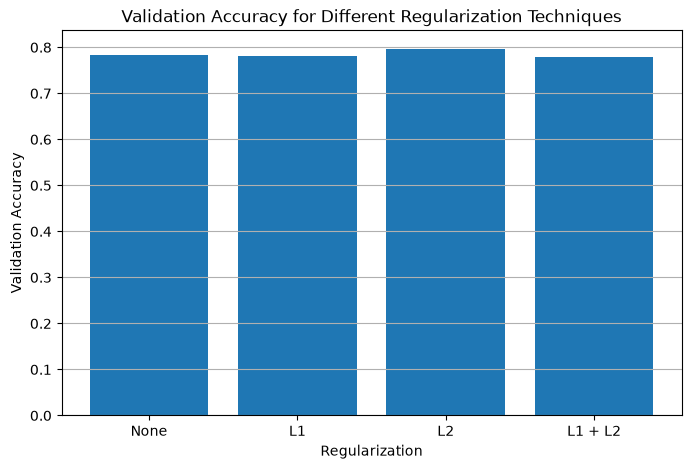

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    regularization_df["Regularization"],
    regularization_df["Validation Accuracy"]
)

plt.title("Validation Accuracy for Different Regularization Techniques")
plt.xlabel("Regularization")
plt.ylabel("Validation Accuracy")

plt.grid(axis="y")

plt.show()

In [ ]:
regularization_df.to_csv(
    "regularization_results.csv",
    index=False
)

### Observation

Among the evaluated regularization techniques, **L2 Regularization** achieved the highest validation and test accuracy while maintaining a relatively small generalization gap. L1 Regularization significantly reduced overfitting but also reduced the model's learning capacity, leading to underfitting. Therefore, **L2 Regularization** was selected for the next experiment (Dropout).

## Part E: Effect of Dropout

In this experiment, different dropout rates were evaluated using the best-performing optimizer (Adam) and regularization technique (L2). The objective was to determine the optimal dropout rate that reduces overfitting while maintaining high classification accuracy.

In [ ]:
dropout_results = []

In [ ]:
history_d0, result_d0 = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2",

    dropout_rate=0.0,

    early_stopping=False,

    epochs=200

)

dropout_results.append(result_d0)

Epoch 1/200


c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7410 - loss: 0.9758 - val_accuracy: 0.7598 - val_loss: 0.8303
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7728 - loss: 0.7466 - val_accuracy: 0.7793 - val_loss: 0.7063
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7775 - loss: 0.6951 - val_accuracy: 0.7810 - val_loss: 0.6770
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7847 - loss: 0.6665 - val_accuracy: 0.7816 - val_loss: 0.6687
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7860 - loss: 0.6503 - val_accuracy: 0.7880 - val_loss: 0.6538
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7893 - loss: 0.6375 - val_accuracy: 0.7801 - val_loss: 0.6631
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7917 - loss: 0.6279 - val_accuracy: 0.7838 - val_loss: 0.6591
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7952 - loss: 0.6161 - val_

In [ ]:
history_d2, result_d2 = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2",

    dropout_rate=0.2,

    early_stopping=False,

    epochs=200

)

dropout_results.append(result_d2)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7176 - loss: 1.0973 - val_accuracy: 0.7640 - val_loss: 0.8220
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7555 - loss: 0.8266 - val_accuracy: 0.7760 - val_loss: 0.7356
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7626 - loss: 0.7615 - val_accuracy: 0.7732 - val_loss: 0.7053
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7653 - loss: 0.7333 - val_accuracy: 0.7811 - val_loss: 0.6797
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7684 - loss: 0.7219 - val_accuracy: 0.7814 - val_loss: 0.6693
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7719 - loss: 0.7106 - val_accuracy: 0.7803 - val_loss: 0.6851
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7723 - loss: 0.7028 - val_accuracy: 0.7827 - val_loss: 0.6736
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7747 - loss: 0

In [ ]:
history_d4, result_d4 = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2",

    dropout_rate=0.4,

    early_stopping=False,

    epochs=200

)

dropout_results.append(result_d4)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6796 - loss: 1.2626 - val_accuracy: 0.7454 - val_loss: 0.9182
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7374 - loss: 0.9240 - val_accuracy: 0.7643 - val_loss: 0.7851
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7461 - loss: 0.8403 - val_accuracy: 0.7735 - val_loss: 0.7368
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7492 - loss: 0.8005 - val_accuracy: 0.7647 - val_loss: 0.7265
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7532 - loss: 0.7878 - val_accuracy: 0.7708 - val_loss: 0.7118
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7545 - loss: 0.7777 - val_accuracy: 0.7760 - val_loss: 0.7089
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7562 - loss: 0.7682 - val_accuracy: 0.7759 - val_loss: 0.7150
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7585 - loss: 0

In [ ]:
history_d5, result_d5 = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2",

    dropout_rate=0.5,

    early_stopping=False,

    epochs=200

)

dropout_results.append(result_d5)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6414 - loss: 1.4059 - val_accuracy: 0.7407 - val_loss: 0.9576
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7252 - loss: 0.9883 - val_accuracy: 0.7593 - val_loss: 0.8284
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7354 - loss: 0.8912 - val_accuracy: 0.7645 - val_loss: 0.7619
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7414 - loss: 0.8448 - val_accuracy: 0.7615 - val_loss: 0.7513
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7444 - loss: 0.8280 - val_accuracy: 0.7680 - val_loss: 0.7413
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7471 - loss: 0.8168 - val_accuracy: 0.7688 - val_loss: 0.7285
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7493 - loss: 0.8109 - val_accuracy: 0.7671 - val_loss: 0.7297
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7473 - loss: 0

In [ ]:
dropout_df = pd.DataFrame(dropout_results)

dropout_df["Generalization Gap"] = (
    dropout_df["Training Accuracy"]
    - dropout_df["Validation Accuracy"]
)

dropout_df

,Optimizer,Regularization,Dropout,Early Stopping,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Test Loss,Epochs,Generalization Gap
0,Adam,L2,0.0,False,0.839590,0.796919,0.792394,0.493832,0.645712,0.656253,200,0.042671
1,Adam,L2,0.2,False,0.795216,0.793687,0.788839,0.636478,0.642633,0.643964,200,0.001530
2,Adam,L2,0.4,False,0.770097,0.789593,0.782051,0.721534,0.673039,0.687553,200,-0.019495
3,Adam,L2,0.5,False,0.757653,0.778927,0.774079,0.768330,0.700461,0.715249,200,-0.021274


### Dropout Analysis

The effect of different dropout rates was evaluated using the Adam optimizer with L2 regularization. The objective was to determine the optimal dropout rate that minimizes overfitting while maintaining high validation and test accuracy.

In [ ]:
### Observation

The model achieved the highest test accuracy without dropout; however, a dropout rate of **0.2** produced the smallest generalization gap while maintaining comparable validation and test accuracy. Higher dropout rates (0.4 and 0.5) reduced both training and test performance, indicating underfitting. Therefore, **Dropout = 0.2** was selected for the final model.

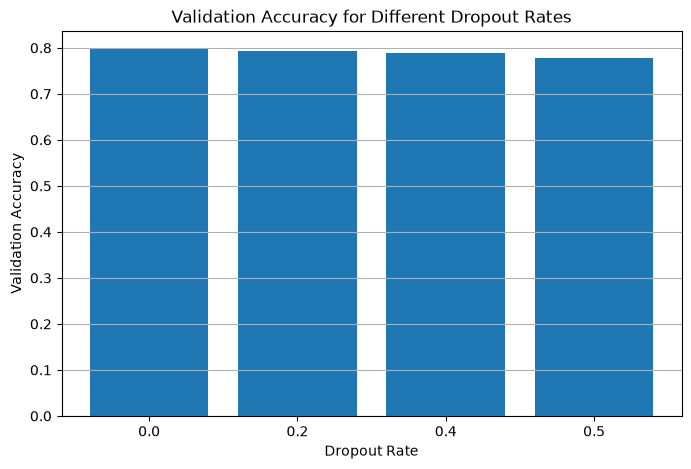

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    dropout_df["Dropout"].astype(str),
    dropout_df["Validation Accuracy"]
)

plt.title("Validation Accuracy for Different Dropout Rates")
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy")

plt.grid(axis="y")

plt.show()

## Part F: Early Stopping

In this experiment, the final model was trained with and without Early Stopping using the best-performing optimizer, regularization technique, and dropout rate. The objective was to compare training time, number of epochs, and model generalization, and evaluate the effectiveness of Early Stopping in preventing overfitting.

In [ ]:
early_stopping_results = []

In [ ]:
history_without_es, result_without_es = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2",

    dropout_rate=0.2,

    early_stopping=False,

    epochs=200

)

early_stopping_results.append(result_without_es)

Epoch 1/200


c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7229 - loss: 1.0829 - val_accuracy: 0.7652 - val_loss: 0.8356
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7520 - loss: 0.8290 - val_accuracy: 0.7735 - val_loss: 0.7401
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7596 - loss: 0.7640 - val_accuracy: 0.7766 - val_loss: 0.7084
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7650 - loss: 0.7370 - val_accuracy: 0.7609 - val_loss: 0.7192
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7678 - loss: 0.7225 - val_accuracy: 0.7846 - val_loss: 0.6847
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7702 - loss: 0.7100 - val_accuracy: 0.7864 - val_loss: 0.6689
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7731 - loss: 0.7037 - val_accuracy: 0.7878 - val_loss: 0.6681
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7734 - loss: 0.6993 - val_

In [ ]:
history_with_es, result_with_es = run_experiment(

    optimizer=Adam(learning_rate=0.001),

    optimizer_name="Adam",

    regularizer=l2(0.001),

    regularization_name="L2",

    dropout_rate=0.2,

    early_stopping=True,

    epochs=200

)

early_stopping_results.append(result_with_es)

Epoch 1/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7163 - loss: 1.1018 - val_accuracy: 0.7663 - val_loss: 0.8349
Epoch 2/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7575 - loss: 0.8288 - val_accuracy: 0.7637 - val_loss: 0.7540
Epoch 3/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7625 - loss: 0.7591 - val_accuracy: 0.7757 - val_loss: 0.7166
Epoch 4/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7651 - loss: 0.7334 - val_accuracy: 0.7856 - val_loss: 0.6799
Epoch 5/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7698 - loss: 0.7194 - val_accuracy: 0.7853 - val_loss: 0.6763
Epoch 6/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7710 - loss: 0.7104 - val_accuracy: 0.7812 - val_loss: 0.6804
Epoch 7/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7743 - loss: 0.7021 - val_accuracy: 0.7857 - val_loss: 0.6664
Epoch 8/200
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7770 - loss: 0

In [ ]:
early_stopping_df = pd.DataFrame(early_stopping_results)

early_stopping_df["Generalization Gap"] = (

    early_stopping_df["Training Accuracy"]

    -

    early_stopping_df["Validation Accuracy"]

)

early_stopping_df

,Optimizer,Regularization,Dropout,Early Stopping,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Test Loss,Epochs,Generalization Gap
0,Adam,L2,0.2,False,0.795309,0.797457,0.791855,0.634773,0.638915,0.647172,200,-0.002149
1,Adam,L2,0.2,True,0.789791,0.787007,0.791532,0.651402,0.652577,0.644063,44,0.002784


In [ ]:
early_stopping_df.to_csv(
    "early_stopping_results.csv",
    index=False
)

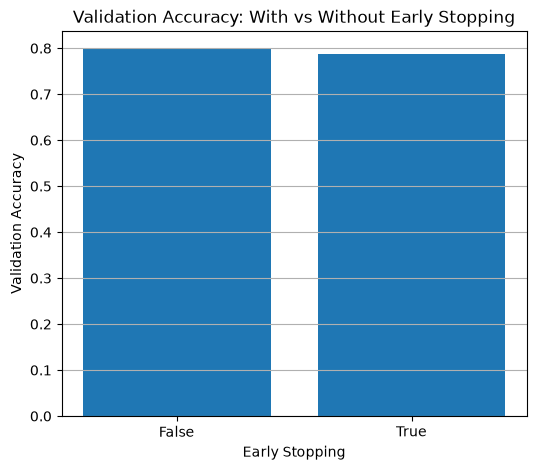

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    early_stopping_df["Early Stopping"].astype(str),
    early_stopping_df["Validation Accuracy"]
)

plt.title("Validation Accuracy: With vs Without Early Stopping")
plt.xlabel("Early Stopping")
plt.ylabel("Validation Accuracy")

plt.grid(axis="y")

plt.show()

### Observation

Early Stopping terminated training after **44 epochs** instead of the full **200 epochs**, significantly reducing training time. Although the validation accuracy was slightly lower than the model trained for 200 epochs, the test accuracy remained nearly identical. This demonstrates that Early Stopping can reduce computational cost while maintaining comparable generalization performance.

## Part G: Comparative Analysis

The best-performing models from each experiment were compared to identify the optimal training strategy. The comparison includes the optimizer, regularization technique, dropout rate, early stopping configuration, validation accuracy, and test accuracy.

In [1]:
final_summary = pd.DataFrame({

    "Model": [
        "Baseline (SGD)",
        "Best Optimizer (Adam)",
        "Best Regularization (L2)",
        "Best Dropout (0.2)",
        "Final Model (Early Stopping)"
    ],

    "Optimizer": [
        "SGD",
        "Adam",
        "Adam",
        "Adam",
        "Adam"
    ],

    "Regularization": [
        "None",
        "None",
        "L2",
        "L2",
        "L2"
    ],

    "Dropout": [
        0.0,
        0.0,
        0.0,
        0.2,
        0.2
    ],

    "Early Stopping": [
        "No",
        "No",
        "No",
        "No",
        "Yes"
    ],

    "Validation Accuracy": [
        0.784206,
        0.784745,
        regularization_df.loc[
            regularization_df["Regularization"] == "L2",
            "Validation Accuracy"
        ].values[0],
        dropout_df.loc[
            dropout_df["Dropout"] == 0.2,
            "Validation Accuracy"
        ].values[0],
        early_stopping_df.loc[
            early_stopping_df["Early Stopping"] == True,
            "Validation Accuracy"
        ].values[0]
    ],

    "Test Accuracy": [
        0.782805,
        0.789054,
        regularization_df.loc[
            regularization_df["Regularization"] == "L2",
            "Test Accuracy"
        ].values[0],
        dropout_df.loc[
            dropout_df["Dropout"] == 0.2,
            "Test Accuracy"
        ].values[0],
        early_stopping_df.loc[
            early_stopping_df["Early Stopping"] == True,
            "Test Accuracy"
        ].values[0]
    ]

})

final_summary

NameError: name 'pd' is not defined

In [ ]:
final_summary.to_csv("final_summary.csv", index=False)

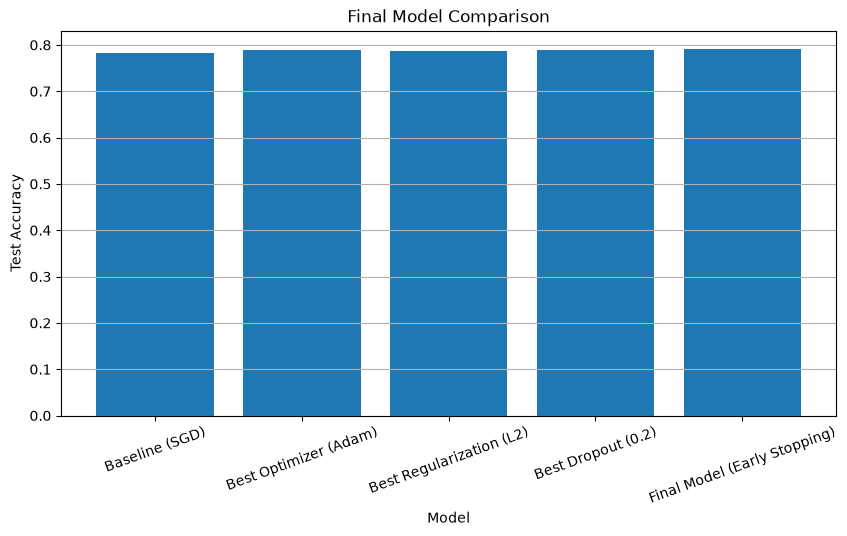

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    final_summary["Model"],
    final_summary["Test Accuracy"]
)

plt.title("Final Model Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

# Discussion Questions

### Q1. Which optimizer converged the fastest?

Based on the experimental results and learning curves, **Adam** converged the fastest. It reached high training and validation accuracy within fewer epochs compared to the other optimizers. Adam also achieved the highest test accuracy (78.91%), making it the best-performing optimizer in this experiment.

### Q2. Why did some optimizers achieve better validation accuracy than others?

Different optimizers update model weights using different optimization strategies. Adam adapts the learning rate for each parameter, allowing faster and more stable convergence. SGD required more epochs to converge, while RMSprop showed poor performance for this dataset. Therefore, Adam achieved better validation accuracy due to its adaptive learning mechanism.

### Q3. Did the model exhibit overfitting?

Yes. The baseline model exhibited overfitting because the training accuracy (approximately 98%) was much higher than the validation accuracy (approximately 78%). This large generalization gap indicated that the model learned the training data well but did not generalize effectively to unseen data.

### Q4. Compare the effects of L1 and L2 regularization.

L1 regularization significantly reduced the generalization gap but also reduced the training accuracy, indicating underfitting. L2 regularization achieved the best balance by reducing overfitting while maintaining high validation and test accuracy. Therefore, L2 regularization provided the best overall performance in this experiment.

### Q5. Why did increasing the dropout rate reduce performance?

Increasing the dropout rate removes more neurons during training. Moderate dropout improves generalization by preventing overfitting; however, excessive dropout (0.4 and 0.5) reduced the model's learning capacity, resulting in lower training, validation, and test accuracy. This indicates underfitting.

### Q6. Effect of Early Stopping

Early Stopping terminated the training after 44 epochs instead of 200 epochs, reducing the training time significantly. Although the validation accuracy decreased slightly, the test accuracy remained nearly unchanged. This demonstrates that Early Stopping reduced computational cost while maintaining comparable generalization performance.

### Q7. Best Model Configuration

The best-performing configuration consisted of the **Adam optimizer**, **L2 regularization**, **dropout rate of 0.2**, and **Early Stopping**. This configuration achieved high test accuracy (79.15%) while reducing training time from 200 epochs to 44 epochs. It also maintained a very small generalization gap, indicating good generalization and reduced overfitting.

### Q8. Recommended Optimization Strategy

If the dataset size increases significantly, I would recommend using the **Adam optimizer** with **L2 regularization**, **dropout rate of 0.2**, and **Early Stopping**. Adam provides faster convergence on large datasets through adaptive learning rates, while L2 regularization and dropout improve generalization. Early Stopping further reduces unnecessary training time, making the overall training process more scalable and computationally efficient.